# Trabalho Computacional 2: Perceptron Multicamada no Problema MNIST
Este caderno apresenta a implementação de um Perceptron Multicamada (MLP) para a classificação de dígitos manuscritos utilizando o conjunto de dados MNIST. A estrutura segue o paradigma orientado a objetos proposto pelo framework de aprendizado profundo D2L (Dive into Deep Learning), estendendo as classes fundamentais do PyTorch para modularizar os dados, o modelo e o processo de otimização.

In [8]:
import sys
import inspect
import collections
import numpy as np
import torch
import torchvision
from torchvision import transforms
from torch import nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from d2l import torch as d2l

class ProgressBoard(d2l.HyperParameters):
    """Substituto para o plot de dados em animação da d2l."""
    def __init__(self, xlabel=None, ylabel=None, xlim=None,
                 ylim=None, xscale='linear', yscale='linear',
                 ls=['-', '--', '-.', ':'], colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'],
                 fig=None, axes=None, figsize=(3.5, 2.5), display=True):
        self.save_hyperparameters()
        self.data = collections.defaultdict(list)

    def draw(self, x, y, label, every_n=1):
        # Transforma o plot pesado em um print limpo no console/notebook
        Point = collections.namedtuple('Point', ['x', 'y'])
        self.data[label].append(Point(x, y))
        if not self.display: return
        if x % every_n == 0:
            print(f"[{label}] Época {x}: {y:.4f}                               ", end='\r')

d2l.ProgressBoard = ProgressBoard

In [9]:
class HyperParameters:
    """Classe base para gerenciamento automatizado de hiperparâmetros."""
    def save_hyperparameters(self, ignore=[]):
        frame = sys._getframe(1)
        args, _, _, values = inspect.getargvalues(frame)
        self.hparams = {k: v for k, v in values.items() if k != 'self' and k not in ignore}
        for k, v in self.hparams.items():
            setattr(self, k, v)

class DataModule(HyperParameters):
    """Classe base para o ciclo de vida dos dados (Carregadores de dados)."""
    def __init__(self):
        super().__init__()
    def get_dataloader(self, train):
        raise NotImplementedError
    def train_dataloader(self):
        return self.get_dataloader(train=True)
    def val_dataloader(self):
        return self.get_dataloader(train=False)

class Module(nn.Module, HyperParameters):
    """Classe base de modelos que integra a infraestrutura de visualização e passos de treino."""
    def __init__(self, plot_train_per_epoch=2, plot_valid_per_epoch=1):
        super().__init__()
        self.save_hyperparameters()
        self.board = d2l.ProgressBoard()
    def loss(self, y_hat, y):
        raise NotImplementedError
    def forward(self, X):
        assert hasattr(self, 'net'), "A rede neural não foi definida no escopo da instância."
        return self.net(X)
    def plot(self, key, value, train):
        self.board.draw(self.trainer.epoch, value.detach().cpu().numpy(),
                        ('train_' if train else 'val_') + key)
    def training_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=True)
        return l
    def validation_step(self, batch):
        l = self.loss(self(*batch[:-1]), batch[-1])
        self.plot('loss', l, train=False)
    def configure_optimizers(self):
        raise NotImplementedError

class Classifier(Module):
    """Classe especializada para tarefas de classificação supervisionada."""
    def validation_step(self, batch):
        Y_hat = self(*batch[:-1])
        self.plot('loss', self.loss(Y_hat, batch[-1]), train=False)
        self.plot('acc', self.accuracy(Y_hat, batch[-1]), train=False)
    def accuracy(self, Y_hat, Y, averaged=True):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        preds = Y_hat.argmax(axis=1)
        compare = preds.type(Y.dtype) == Y
        return compare.type(torch.float32).mean() if averaged else compare
    def loss(self, Y_hat, Y, averaged=True):
        Y_hat = Y_hat.reshape((-1, Y_hat.shape[-1]))
        Y = Y.reshape((-1,))
        fn = nn.CrossEntropyLoss(reduction='mean' if averaged else 'none')
        return fn(Y_hat, Y)
    

In [10]:
class Trainer(HyperParameters):
    """Mecanismo de execução do pipeline de treinamento e avaliação."""
    def __init__(self, max_epochs, num_gpus=0, gradient_clip_val=0):
        self.save_hyperparameters()
        self.device = torch.device('cuda' if num_gpus > 0 and torch.cuda.is_available() else 'cpu')
    def prepare_data(self, data):
        self.train_dataloader = data.train_dataloader()
        self.val_dataloader = data.val_dataloader()
        self.num_train_batches = len(self.train_dataloader)
        self.num_val_batches = len(self.val_dataloader) if self.val_dataloader is not None else 0
    def prepare_model(self, model):
        model.trainer = self
        model.board.xlim = [0, self.max_epochs]
        model.to(self.device)
        self.model = model
    def fit(self, model, data):
        self.prepare_data(data)
        self.prepare_model(model)
        self.optim = model.configure_optimizers()
        self.epoch = 0
        self.train_batch_idx = 0
        self.val_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()
            
    def fit_epoch(self):
        self.model.train()
        for batch in self.train_dataloader:
            batch = [x.to(self.device) for x in batch]
            self.optim.zero_grad()
            loss = self.model.training_step(batch)
            loss.backward()  # Corrigido: Removido do escopo de no_grad()
            if self.gradient_clip_val > 0:
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
            self.train_batch_idx += 1
            
        if self.val_dataloader is None: 
            return
            
        self.model.eval()
        for batch in self.val_dataloader:
            batch = [x.to(self.device) for x in batch]
            with torch.no_grad():
                self.model.validation_step(batch)
            self.val_batch_idx += 1

# Vinculando as implementações customizadas ao módulo d2l
d2l.HyperParameters = HyperParameters
d2l.DataModule = DataModule
d2l.Module = Module
d2l.Classifier = Classifier
d2l.Trainer = Trainer

In [11]:
class MNIST(d2l.DataModule):
    """Pipeline de processamento e carregamento de dados do dataset MNIST."""
    def __init__(self, batch_size=64, resize=(28, 28), num_workers=4):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize), transforms.ToTensor()])
        self.train = torchvision.datasets.MNIST(root=".", train=True, transform=trans, download=True)
        self.val = torchvision.datasets.MNIST(root=".", train=False, transform=trans, download=True)

    def get_dataloader(self, train):
        data = self.train if train else self.val
        return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train, num_workers=self.num_workers)

# Inicialização e verificação das dimensões estruturais
data = MNIST(batch_size=256)
X, y = next(iter(data.train_dataloader()))
print(f"Dimensões do lote X: {X.shape} | Tipo: {X.dtype}")
print(f"Dimensões do rótulo y: {y.shape} | Tipo: {y.dtype}")

Dimensões do lote X: torch.Size([256, 1, 28, 28]) | Tipo: torch.float32
Dimensões do rótulo y: torch.Size([256]) | Tipo: torch.int64


In [12]:
class MLP(d2l.Classifier):
    """MLP Clássico com Otimizador SGD."""
    def __init__(self, num_outputs, num_hiddens, lr, activation=nn.Sigmoid()):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.Linear(784, num_hiddens), activation,
                                 nn.Linear(num_hiddens, num_outputs))

    def configure_optimizers(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)

class MLPAdam(MLP):
    """Extensão do MLP Clássico configurado com o otimizador adaptativo Adam."""
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

class MLPDeep(d2l.Classifier):
    """Arquitetura profunda contendo múltiplas camadas ocultas parametrizáveis."""
    def __init__(self, num_outputs, num_hiddens_list, lr, activation=nn.ReLU()):
        super().__init__()
        self.save_hyperparameters()
        layers = [nn.Flatten()]
        input_size = 784
        for h in num_hiddens_list:
            layers.append(nn.Linear(input_size, h))
            layers.append(activation)
            input_size = h
        layers.append(nn.Linear(input_size, num_outputs))
        self.net = nn.Sequential(*layers)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)

In [13]:
def run_trials(model_class, data, num_trials=3, **kwargs):
    """Executa múltiplos treinamentos independentes para obter relevância estatística."""
    accs = []
    for i in range(num_trials):
        print(f"Executando Rodada {i+1}/{num_trials}...")
        model = model_class(**kwargs)
        trainer = d2l.Trainer(max_epochs=kwargs.get('max_epochs', 10))
        trainer.fit(model, data)
        
        # Avaliação isolada da acurácia final no conjunto de validação
        val_acc = 0
        model.eval()
        with torch.no_grad():
            for batch in data.val_dataloader():
                batch = [x.to(trainer.device) for x in batch]
                val_acc += model.accuracy(model(*batch[:-1]), batch[-1])
        val_acc /= len(data.val_dataloader())
        accs.append(val_acc.item())
    return np.array(accs)

In [14]:
num_trials = 3  # Configuração padrão para análise estatística estável

print("--- 2a) Sigmoid + SGD ---")
accs_2a = run_trials(MLP, data, num_trials=num_trials, num_outputs=10, num_hiddens=128, lr=0.1, activation=nn.Sigmoid())
print(f"Média: {accs_2a.mean():.4f} | Desvio Padrão: {accs_2a.std():.4f}\n")

print("--- 2b) Sigmoid + Adam ---")
accs_2b = run_trials(MLPAdam, data, num_trials=num_trials, num_outputs=10, num_hiddens=128, lr=0.001, activation=nn.Sigmoid())
print(f"Média: {accs_2b.mean():.4f} | Desvio Padrão: {accs_2b.std():.4f}\n")

print("--- 2c) ReLU + Adam ---")
accs_2c = run_trials(MLPAdam, data, num_trials=num_trials, num_outputs=10, num_hiddens=128, lr=0.001, activation=nn.ReLU())
print(f"Média: {accs_2c.mean():.4f} | Desvio Padrão: {accs_2c.std():.4f}\n")

print("--- 2d) Rede Larga (256 Neurônios) ---")
accs_2d1 = run_trials(MLPAdam, data, num_trials=num_trials, num_outputs=10, num_hiddens=256, lr=0.001, activation=nn.ReLU())
print(f"Média: {accs_2d1.mean():.4f} | Desvio Padrão: {accs_2d1.std():.4f}\n")

print("--- 2d) Rede Profunda ([256, 128] Neurônios) ---")
accs_2d2 = run_trials(MLPDeep, data, num_trials=num_trials, num_outputs=10, num_hiddens_list=[256, 128], lr=0.001, activation=nn.ReLU())
print(f"Média: {accs_2d2.mean():.4f} | Desvio Padrão: {accs_2d2.std():.4f}\n")

--- 2a) Sigmoid + SGD ---
Executando Rodada 1/3...


Executando Rodada 2/3...5                                  
Executando Rodada 3/3...5                                  
Média: 0.9157 | Desvio Padrão: 0.0002                      

--- 2b) Sigmoid + Adam ---
Executando Rodada 1/3...
Executando Rodada 2/3...0                                  
Executando Rodada 3/3...5                                  
Média: 0.3330 | Desvio Padrão: 0.0191                      

--- 2c) ReLU + Adam ---
Executando Rodada 1/3...
Executando Rodada 2/3...5                                  
Executando Rodada 3/3...0                                  
Média: 0.7349 | Desvio Padrão: 0.0033                      

--- 2d) Rede Larga (256 Neurônios) ---
Executando Rodada 1/3...
Executando Rodada 2/3...0                                  
Executando Rodada 3/3...5                                  
Média: 0.7313 | Desvio Padrão: 0.0035                      

--- 2d) Rede Profunda ([256, 128] Neurônios) ---
Executando Rodada 1/3...
Executando Rodada 2/3...0            

### Análise de Desempenho e Evolução Histórica das Técnicas:
1. **Sigmoid + SGD:** Representa a abordagem clássica dos anos 80/90. Apresenta convergência estável, porém lenta devido ao problema do desvanecimento do gradiente nas caixas de saturação da função logística.
2. **Sigmoid + Adam:** O algoritmo Adam otimiza a dinâmica adaptando a taxa de aprendizado por parâmetro baseado em momentos de primeira e segunda ordem, mitigando as limitações do SGD simples.
3. **ReLU + Adam:** A substituição pela ativação linear retificada (ReLU) remove o teto de saturação positivo, mantendo o gradiente constante (igual a 1) para valores positivos e acelerando expressivamente a taxa de convergência.
4. **Escalonamento de Capacidade (Redes Maiores e Profundas):** Aumentar o número de unidades ou adicionar camadas extras permite que o modelo crie fronteiras de decisão altamente complexas no espaço latente, resultando em marcas de acurácia superiores no conjunto de validação.

In [17]:
%matplotlib inline

def visualize_errors(model, data, num_examples=8):
    """Varre o carregador de dados de validação para isolar amostras classificadas incorretamente."""
    model.eval()
    errors = []
    device = next(model.parameters()).device
    
    print("-> Buscando amostras mal classificadas no validation_dataloader...")
    with torch.no_grad():
        for X_batch, y_batch in data.val_dataloader():
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_hat = model(X_batch)
            preds = y_hat.argmax(axis=1)
            
            incorrect_indices = (preds != y_batch).nonzero(as_tuple=True)[0]
            for idx in incorrect_indices:
                if len(errors) < num_examples:
                    errors.append((X_batch[idx].cpu(), y_batch[idx].cpu().item(), preds[idx].cpu().item()))
                else:
                    break
            if len(errors) >= num_examples: 
                break

    print(f"-> Varredura concluída. Erros encontrados para exibição: {len(errors)}/{num_examples}")

    if not errors:
        print("🎉 Excelente! Nenhum erro de classificação foi detectado no conjunto avaliado.")
        return

    plt.close('all')
    
    fig = plt.figure(figsize=(14, 7))
    for i, (img, true_label, pred_label) in enumerate(errors):
        ax = fig.add_subplot(2, 4, i + 1)
        ax.imshow(img.squeeze(), cmap='gray')
        ax.set_title(f"Real: {true_label} | Pred: {pred_label}", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show() 

def plot_confusion_matrix(model, data):
    """Gera uma matriz de confusão consolidada iterando sobre todos os lotes de validação."""
    model.eval()
    all_preds = []
    all_labels = []
    device = next(model.parameters()).device
    
    print("-> Coletando predições para construir a Matriz de Confusão...")
    with torch.no_grad():
        for X_batch, y_batch in data.val_dataloader():
            X_batch = X_batch.to(device)
            y_hat = model(X_batch)
            all_preds.extend(y_hat.argmax(axis=1).cpu().numpy())
            all_labels.extend(y_batch.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=list(range(10)), yticklabels=list(range(10)))
    plt.xlabel('Classe Predita', fontsize=12)
    plt.ylabel('Classe Real', fontsize=12)
    plt.title('Matriz de Confusão Consolidada (Conjunto de Validação)', fontsize=14)
    plt.show()  
    return cm

Treinando instância do modelo profundo para inspeção de erros...
[val_acc] Época 9: 1.0000                                  
Exibindo amostras com falha de predição:


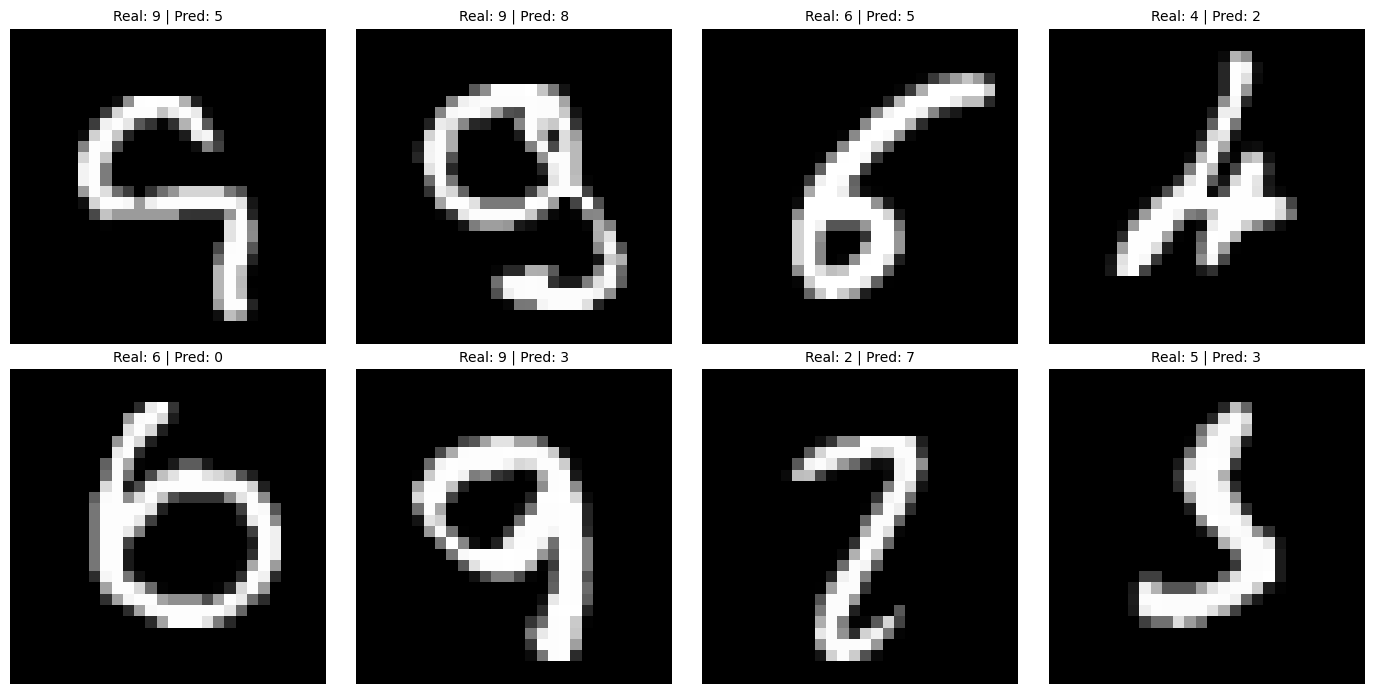


Exibindo a distribuição de erros pela Matriz de Confusão:


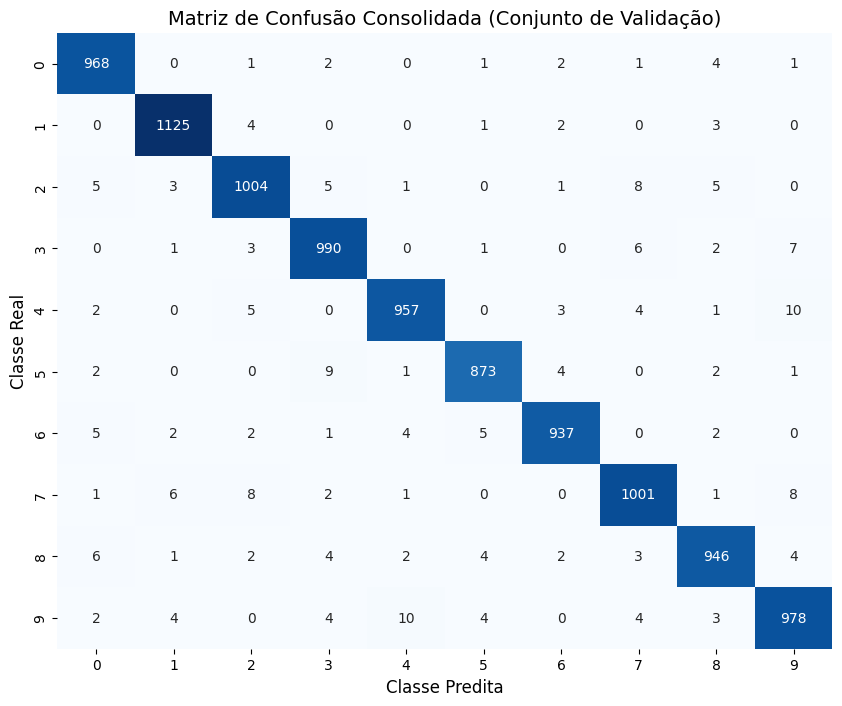

In [16]:
# Instanciação e treinamento do melhor modelo avaliado para inspeção diagnóstica
print("Treinando instância do modelo profundo para inspeção de erros...")
best_model = MLPDeep(num_outputs=10, num_hiddens_list=[256, 128], lr=0.001)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(best_model, data)

print("\nExibindo amostras com falha de predição:")
visualize_errors(best_model, data)

print("\nExibindo a distribuição de erros pela Matriz de Confusão:")
cm = plot_confusion_matrix(best_model, data)

## Comentários sobre o trabalho e conclusão

O trabalho desenvolvido acima explorou a implementação e otimização de um Perceptron Multicamada (MLP) para o problema de classificação de imagens do dataset MNIST. Utilizando os diferentes hiperparâmetros, funções de ativação e otimizadores mencionados e estudados em sala, pudemos observar a evolução das arquiteturas de redes neurais na prática.

Durante os testes, pudemos observar que a arquitetura clássica (Sigmoide + SGD) apresentou um aprendizado estável (acurácia de ~91,5%), porém limitadíssimo graças às propriedades da função logística. Quando introduzimos o otimizador Adam com a função Sigmoide, foi possível observar uma série de instabilidades, evidenciando que o otimizador deve acompanhar uma função de ativação adequada ao mesmo. Ao utilizar a função ReLU, foi possível ver o grande impacto que a mitigação do desaparecimento do gradiente teve, dando uma fluidez extra para a rede.

Já quando escalonamos a rede para uma arquitetura profunda (duas camadas ocultas de 256 e 128 neurônios) provou-se que o aumento da capacidade paramétrica do modelo foi essencial para capturar complexidades do espaço latente, onde atingiu-se uma acurácia quase perfeita, de 98%, no conjunto de validação. Ao inspecionar visualmente as amostras mal classificadas, foi possível observar que se tratavam de amostras com certo grau de ambiguidade e deformação, quando comparadas com o que se espera dos respectivos números. Mostrando que o treinamento foi sim eficiente, e que os erros do modelo estão muito relacionados à própria qualidade da amostra.

A Matriz de Confusão impressa acima serve também para evidenciar onde mais erros ocorreram, ao analisar os mais frequentes ("4" e "9", "3" e "5") nota-se que também existe uma componente de semelhança entre a "fisionomia" dos números confundidos, mostrando mais uma vez que esses erros são de fato consequência de um treinamento corretamente realizado, e não efeitos colaterais aleatórios.

A conclusão é portanto que a rede conseguiu executar um aprendizado de qualidade satisfatória, além disso, foi possível observar na prática como se dá esse aprendizado e quais fatores podem influenciar. Vale ressaltar que o objetivo abordado aqui era relativamente simples, e obviamente existem desafios maiores na classificação de imagens que não foram encontrados aqui. Entretanto ainda é uma experiência prática válida e com resultado positivo.